## Goal of this notebook:
Summarize the segdup characteristics + 
For each regions of interest calculate how many segmental duplicated region it is linked to 

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# Read BEDPE file
bedpe = pd.read_csv(
    "/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/code/command-line-script/genome-annotation/biser/hifiasm-041425/segdup_output_duplicateLinkRemoved.bedpe",
    sep="\t",
    header=None,
    names=["chr1", "start1", "end1", "chr2", "start2", "end2","reference","score","strand1","strand2","max_len","aln_len","cigar","optional"]
)

# bedpe = bedpe.sample(frac=0.1, random_state=28)  # random 1000 rows
df = bedpe.copy()

In [22]:
from pycirclize import Circos
from matplotlib.colors import to_hex, to_rgba
from pycirclize.parser import Gff
import matplotlib.patches as mpatches
import numpy as np
from Bio.SeqFeature import SeqFeature, FeatureLocation


chr_colors = {
    'chr1': '#FF6B6B', 'chr2': '#4ECDC4', 'chr3': '#45B7D1', 'chr4': '#FFA07A',
    'chr5': '#92D050', 'chr6': '#D35FB7', 'chr7': '#FFC000', 'chr8': '#00B0F0',
    'chr9': '#A2D96C', 'chr10': '#C00000', 'chr11': '#7030A0', 'chr12': '#FF5733',
    'chr13': '#00AEEF', 'chr14': '#FF99CC', 'chr15': '#8FD8D8', 'chr16': '#F6546A',
    'chr17': '#468499', 'chr18': '#FFD700', 'chr19': '#088DA5', 'chr20': '#F08080',
    'chr21': '#6A5ACD', 'chr22': '#65B891', 'chr23': '#FFA500', 'chr24': '#BA55D3',
    'chr25': '#9370DB', 'chr26': '#3CB371', 'chr27': '#7B68EE', 'chr28': '#40E0D0',
    'chrX': '#FF1493',  # Distinct pink for X
    'chrY': '#14FF82'   # Dark blue for Y
}
search_terms = ["Larp7", "Cct4", "Cct7","Cct3"]
# search_terms = ["Larp7","Cct3"]

In [23]:
## Get the gff features
gff_feat = Gff("/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/code/command-line-script/annotation-merging/output/hifiasm-041425-denovoEnhanced_peaks2utr_sorted.agat.gff3")

seqid2features = gff_feat.get_seqid2features(feature_type=None)
seqid2features

## Get the segdup links 
bedpe=df.copy()

In [24]:
## This is filtering the features to find the genes that contains these gene signatures 
matching_features = {}

for seqid, features in seqid2features.items():
    for feature in features:
        if hasattr(feature, 'qualifiers') and feature.qualifiers:
            # Search in the most relevant qualifier keys
            relevant_keys = ['gene', 'product', 'Name', 'ID']
            
            for key in relevant_keys:
                if key in feature.qualifiers:
                    for value in feature.qualifiers[key]:
                        value_str = str(value)
                        # Check if any search term is a substring of the value
                        if any(term in value_str for term in search_terms):
                            if seqid not in matching_features:
                                matching_features[seqid] = []
                            matching_features[seqid].append(feature)
                            break
                    else:
                        continue
                    break  # Break outer loop if match found

print(f"Found features across {len(matching_features)} sequences:")
for seqid, features in matching_features.items():
    print(f"  {seqid}: {len(features)} features")

Found features across 14 sequences:
  chrX: 1 features
  chrY: 1 features
  chr1: 30 features
  chr2: 5 features
  chr3: 3 features
  chr5: 1 features
  chr7: 1 features
  chr8: 2 features
  chr9: 2 features
  chr13: 2 features
  chr16: 2 features
  chr17: 1 features
  chr18: 3 features
  chr22: 54 features


In [25]:
# Extract the gene regions from matching_features
gene_regions = {}
for seqid, features in matching_features.items():
    for feature in features:
        if feature.type == "gene":
            gene_name = None
            # Extract gene name from qualifiers
            if hasattr(feature, 'qualifiers') and feature.qualifiers:
                for key in ['gene', 'Name', 'ID']:
                    if key in feature.qualifiers:
                        gene_name = feature.qualifiers[key][0]
                        break
            
            if gene_name:
                gene_regions[gene_name] = {
                    'chrom': seqid,
                    'start': feature.location.start,
                    'end': feature.location.end,
                    'strand': feature.location.strand
                }

print("Gene regions found:")
for gene, region in gene_regions.items():
    print(f"{gene}: {region['chrom']}:{region['start']}-{region['end']}")


Gene regions found:
Larp7-dl5: chrX:51504000-51505395
Cct4-dl2: chrY:40377976-40379801
Larp7-dl1: chr1:15814634-15815186
Larp7: chr1:93499046-93522497
LOC101582363: chr1:122150132-122151501
LOC101561532: chr2:42443323-42445134
Larp7-dl4: chr2:87958355-87959257
Cct7-dl3: chr3:15271857-15273642
Cct7-dl4: chr3:144006210-144007836
Cct3-dl1: chr5:7266506-7268431
Cct3-dl2: chr7:75738243-75740176
LOC111814130: chr8:95017377-95040244
Cct7-dl5: chr9:88499443-88501220
Cct7-dl1: chr13:49716935-49718161
Larp7-dl2: chr16:41417266-41419525
Larp7-dl3: chr17:62111268-62111820
Cct7-dl2: chr18:65319234-65320341
Cct4-dl1: chr18:83873283-83875084
Cct7: chr22:27804213-27826907
Cct4: chr22:39392291-39414603
Cct3: chr22:56156233-56180250


In [31]:
# Find segdup links that overlap these gene regions - return as DataFrame
def find_containing_segdups(gene_regions, bedpe_df):
    # Create a list to store matching row indices
    matching_indices = []
    
    for gene_name, region in gene_regions.items():
        chrom = region['chrom']
        start = region['start']
        end = region['end']
        
        # Find segdup links where this region overlaps either region1 or region2
        mask = (
            ((bedpe_df['chr1'] == chrom) & (bedpe_df['start1'] < end) & (bedpe_df['end1'] > start)) |
            ((bedpe_df['chr2'] == chrom) & (bedpe_df['start2'] < end) & (bedpe_df['end2'] > start))
        )
        
        # Get indices of matching rows
        gene_matching_indices = bedpe_df[mask].index.tolist()
        matching_indices.extend(gene_matching_indices)
    
    # Remove duplicates and return the filtered DataFrame
    unique_indices = list(set(matching_indices))
    containing_links_df = bedpe_df.loc[unique_indices].copy()
    
    # Add gene information to the DataFrame
    gene_info = []
    for idx in unique_indices:
        row = bedpe_df.loc[idx]
        genes_in_link = []
        for gene_name, region in gene_regions.items():
            chrom = region['chrom']
            start = region['start']
            end = region['end']
            if ((row['chr1'] == chrom and row['start1'] < end and row['end1'] > start) or
                (row['chr2'] == chrom and row['start2'] < end and row['end2'] > start)):
                genes_in_link.append(gene_name)
        gene_info.append(', '.join(genes_in_link))
    
    containing_links_df['contained_genes'] = gene_info
    
    return containing_links_df

# Get the containing segdup links as DataFrame
containing_links_df = find_containing_segdups(gene_regions, bedpe)


In [32]:
bed_hotspots = pd.read_csv(
    "segdup_hotspots_80percLength.tsv",
    sep="\t", index_col=False)
print(bed_hotspots.shape)
gene_hotspots = pd.read_csv(
    "segdup_genes_hotspots_80percLength.tsv",
    sep="\t", index_col=False)

# genes_all = pd.read_csv("hifiasm_gene_segDup_overlapInfo_081726.tsv", sep="\t")
# genes_all["Start"] = genes_all["Start"].astype(int)
# genes_all["End"] = genes_all["End"].astype(int)
# genes_all["overlaps_dup"] = genes_all["overlaps_dup"].astype(bool)


(1425, 14)


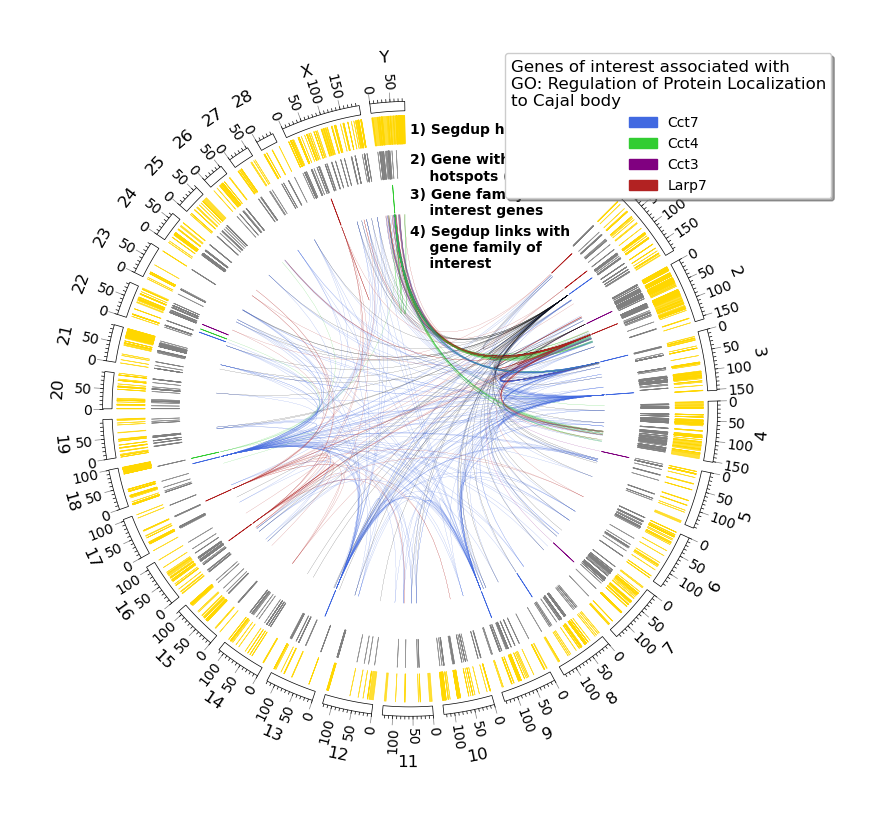

In [33]:
size=12
# Define gene colors
gene_colors = {
    "Cct7": "royalblue",
    "Cct4": "limegreen",
    "Cct3": "purple",
    "Larp7": "firebrick"
}
search_terms = ["Larp7", "Cct4", "Cct7", "Cct3"]

## GPT
# Suppose karyotype is a DataFrame with 'chr' and 'length' columns
# 1. Read the .fai file
fai = pd.read_csv(
    "/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/data/denovo_OctDegus_genome/041425-assembly/hifiasm-041425-assembly-mitoFiltered-scaffolded-curated-masked-chrNameAssigned/assembly_final.sorted.headerRenamed.chrAssigned.hardMasked.mito.fasta.fai",
    sep="\t",
    header=None,
    names=["chr", "length", "offset", "linebases", "linewidth"]
)

# 2. Filter for chromosomes and keep first 4
karyotype = fai[fai["chr"].str.contains("chr")].head(30)[["chr", "length"]]

# 3. Set gap degrees (5° after last chromosome)
gap_degrees = 5
gap_after = [1] * (len(karyotype) - 1) + [gap_degrees]

chr_sizes = dict(zip(karyotype['chr'], karyotype['length']))
# circos = Circos(sectors=chr_sizes, start=10, end=350, space=2, endspace=False)
circos = Circos(sectors=chr_sizes, start=45, end=359, space=2, endspace=False)

###############################################################

for sector in circos.sectors:
    outer = sector.add_track((95, 98), name="axis_track")
    outer.axis(fc="none", ec="black", lw=0.5)

    interval = 50_000_000  # 50 Mb
    outer.xticks_by_interval(
        interval=interval,
        tick_length=3,
        outer=True,
        show_label=True,
        label_size=size-2,
        label_orientation="vertical",
        label_formatter=lambda v: f"{v/1e6:.0f}",
        line_kws=dict(ec="grey")
    )

    # **Minor ticks every 10 Mb without labels**
    outer.xticks_by_interval(
        interval=10_000_000,
        tick_length=1,
        outer=True,
        show_label=False,
        line_kws=dict(ec="black", lw=0.5)
    )

    # Place label at the sector center, just outside the ticks
    center_x = (sector.start + sector.end) / 2
    sector.text(
        text=sector.name.replace("chr", ""),   # ✅ remove 'chr'
        x=center_x,
        r=110,
        adjust_rotation=True,
        size=size ,
        color="black",
        rotation=90
    )

    ## Plot the bed segdup hotspot 
    hotspot_track = sector.add_track((94, 84), r_pad_ratio=0.1)
    features_this_chr = bed_hotspots[bed_hotspots['Chromosome'] == sector.name]
    
    features_to_plot = []
    for _, row in features_this_chr.iterrows():
        feature = SeqFeature(
            FeatureLocation(int(row['Start']), int(row['End'])),
        )
        features_to_plot.append(feature)
    
    hotspot_track.genomic_features(
        features_to_plot,
        fc="gold",
        ec="gold",
        lw=0.5,
        alpha=0.8
    )

    ## Plot the genes within  segdup hotspot 
    gene_hotspot_track = sector.add_track((83, 73), r_pad_ratio=0.1)
    features_this_chr = gene_hotspots[gene_hotspots['Chromosome'] == sector.name]
    
    features_to_plot = []
    for _, row in features_this_chr.iterrows():
        feature = SeqFeature(
            FeatureLocation(int(row['Start']), int(row['End'])),
        )
        features_to_plot.append(feature)
    
    gene_hotspot_track.genomic_features(
        features_to_plot,
        fc="grey",
        ec="grey",
        lw=0.5,
        alpha=0.8
    )


    ###########===> Gene features
    # Plot gene features (full gene spans of genes of interest)
    gene_track = sector.add_track((72, 62), r_pad_ratio=0.1)

    # Check if sector.name is in the matching_features
    if sector.name in matching_features:
        for feature in matching_features[sector.name]:
            if feature.type == "gene":
                # Default color if no specific gene is found
                color = "gray"
                
                # Check qualifiers for search terms
                if hasattr(feature, 'qualifiers') and feature.qualifiers:
                    for key in ['gene', 'product', 'Name', 'ID', 'Parent']:
                        if key in feature.qualifiers:
                            for value in feature.qualifiers[key]:
                                value_str = str(value)
                                # Find which search term is in this value
                                for term in search_terms:
                                    if term in value_str:
                                        color = gene_colors[term]
                                        break  # Use first match
                                else:
                                    continue
                                break  # Break outer loop if match found
                            else:
                                continue
                            break  # Break qualifier key loop if match found
                
                # Plot with determined color
                gene_track.genomic_features(feature, fc=color, ec=color, lw=0.5)

############## ====> Segdup links
bedpe = containing_links_df.copy()

# Filter for valid chromosomes
valid_chrs = list(chr_sizes.keys())
bedpe_filtered = bedpe[
    (bedpe["chr1"].isin(valid_chrs)) & 
    (bedpe["chr2"].isin(valid_chrs))
]


# Plot links with conditional coloring
for _, row in bedpe_filtered.iterrows():
    region1 = (row['chr1'], row['start1'], row['end1'])
    region2 = (row['chr2'], row['start2'], row['end2'])
    
    # Determine color based on contained_genes
    contained_genes = row['contained_genes']
    color = "black"  # default color
    
    # Check each gene in our color dictionary
    for gene, gene_color in gene_colors.items():
        if gene in contained_genes:
            color = gene_color
            break
    
    # Different linewidths for intra vs inter-chromosomal
    lw = 0.1 if row['chr1'] == row['chr2'] else 0.1
    
    circos.link(
        region1, 
        region2, 
        color=color, 
        direction=1, 
        lw=lw
    )

# Plot the figure first
fig = circos.plotfig()

# ✅ Now add your legends using circos.ax
legend_handles = []
for gene, color in gene_colors.items():
    patch = mpatches.Patch(color=color, label=gene)
    legend_handles.append(patch)

# Add default color for other genes
default_patch = mpatches.Patch(color='gray', label='Other genes')
legend_handles.append(default_patch)

# Add gene legend to the circos plot
circos.ax.legend(
    handles=legend_handles,
    loc='upper right',
    bbox_to_anchor=(1.15, 1.0),  # Adjusted to be further right
    frameon=True,
    fancybox=True,
    shadow=True,
    ncol=1,
    fontsize=size,
    title='Genes',
    title_fontsize=size
)

# If you want both legends, create a combined one
combined_handles = []
for gene, color in gene_colors.items():
    combined_handles.append(mpatches.Patch(color=color, label=f'{gene}'))
# combined_handles.append(mpatches.Patch(color='gray', label='Other genes'))
# combined_handles.append(mpatches.Patch(color='black', label='Other segdup'))

# Add single combined legend
circos.ax.legend(
    handles=combined_handles,
    loc='upper right',
    bbox_to_anchor=(1.15, 1.05),
    frameon=True,
    fancybox=True,
    shadow=True,
    ncol=1,
    fontsize=10,
    title='Gene of interest',
    title_fontsize=size
)

# GO subtitle -- much smaller, wrapped below the legend title
circos.ax.text(
    1.15, 0.97,
    'GO: Regulation of Protein\nLocalization to Cajal body',
    transform=circos.ax.transAxes,
    ha='right',
    va='top',
    fontsize=size - 4,
    linespacing=1.4,
    color='#222222'
)

ax = fig.axes[0]  # Get the polar axes

# Define label positions (track_top, text, color)
track_labels = [
    # (95, "Chromosomes", "black"),
    # (89.5, "Forward CDS", "tomato"),
    # (84.5, "Reverse CDS", "dodgerblue"),
    (85, "1) Segdup hotspots", "black"),
    (70, "2) Gene within segdup\n    hotspots (n=1271)", "black"),
    (59, "3) Gene family of\n    interest genes", "black"),
    (42, "4) Segdup links with\n    gene family of\n    interest", "black"),

]

# Add each label in the gap space (0° angle)
for track_top, text, color in track_labels:
    ax.text(
        np.deg2rad(-0),       # 0° angle (center of gap)
        track_top + 2,     # Place text just above track
        text,
        rotation=0,          # Keep horizontal
        ha='left',
        va='bottom',
        color=color,
        size=size-2,
        fontweight='bold'
    )

fig.tight_layout()

In [ ]:
# Save in PNG (lossless) or PDF/SVG (vector)
fig.savefig(
    "degus_genome_circos_segdup_hotspot.png",  # For PNG
    dpi=600,               # Ultra-high resolution (300-600 for print)
    bbox_inches="tight",   # Prevents cropping
    transparent=False,     # Set to True if you need transparency
    facecolor="white"      # Background color
)